In [ ]:
import pandas as pd
# Sample dataset: Word frequency of "democracy" in books
data = {'Year': [1800, 1850, 1900, 1950, 2000],
        'Frequency': [200, 500, 1100, 2500, 4000]}
df = pd.DataFrame(data)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')  # Convert to datetime
# Normalize the frequency
df['Normalized_Frequency'] = (df['Frequency'] - df['Frequency'].min()) / (df['Frequency'].max() - df['Frequency'].min())
print(df)

        Year  Frequency  Normalized_Frequency
0 1800-01-01        200              0.000000
1 1850-01-01        500              0.078947
2 1900-01-01       1100              0.236842
3 1950-01-01       2500              0.605263
4 2000-01-01       4000              1.000000


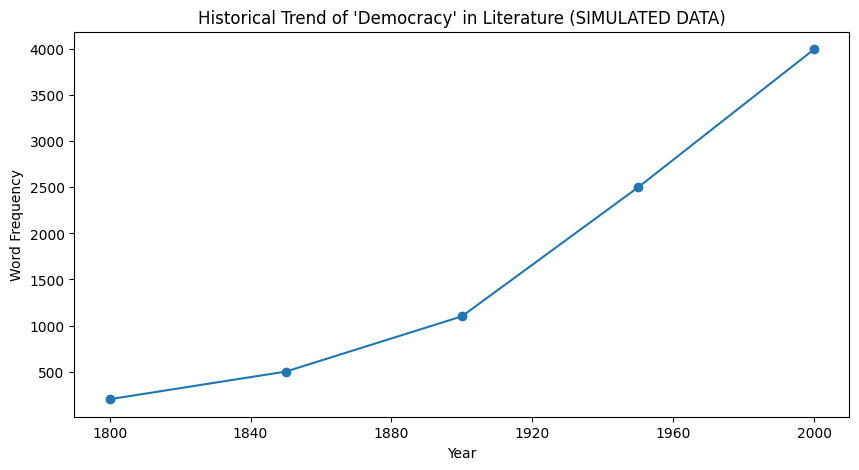

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['Frequency'], marker='o', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Word Frequency")
plt.title("Historical Trend of 'Democracy' in Literature (SIMULATED DATA)")
plt.savefig("democracy_trend.png")
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decomposing the time series
df.set_index('Year', inplace=True)
decomposition = seasonal_decompose(df['Frequency'], model='additive', period=10)
decomposition.plot()
plt.savefig("timeseries_decomposition.png")
plt.show()

ValueError: x must have 2 complete cycles requires 20 observations. x only has 5 observation(s)

In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt

# Initialize pytrends
pytrends = TrendReq(hl='en-US', tz=360)

# Build payload
keywords = ['democracy', 'liberty']
pytrends.build_payload(keywords, timeframe='all')

# Get data
data = pytrends.interest_over_time()

# Plot
plt.figure(figsize=(12, 6))
data.plot(figsize=(12, 6))
plt.title("Google Trends for 'Democracy' and 'Liberty'")
plt.xlabel('Year')
plt.ylabel('Search Interest')
plt.grid(True)
plt.savefig('trends.png')
plt.show()


TooManyRequestsError: The request failed: Google returned a response with code 429

In [ ]:
!pip install pytrends

<Figure size 1200x600 with 0 Axes>

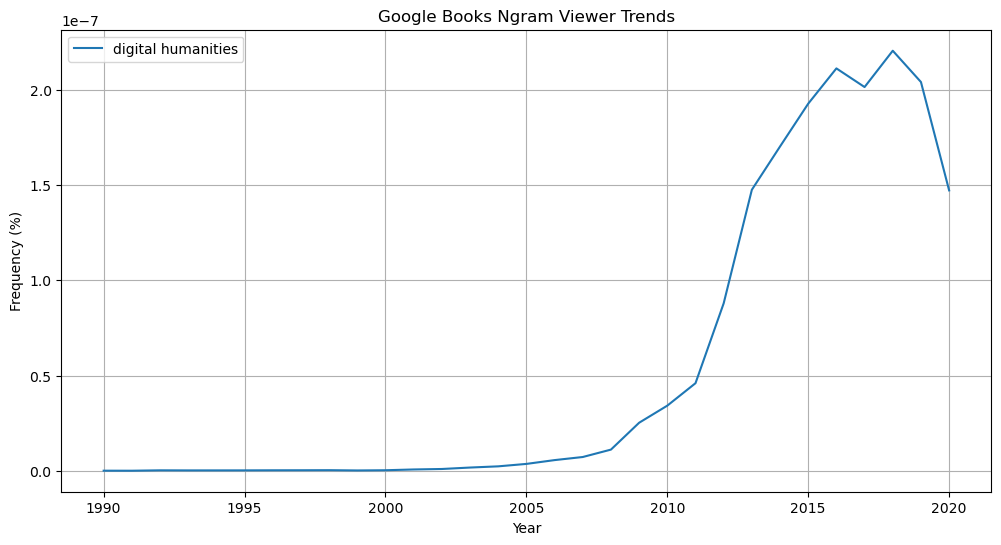

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

def get_ngram_data(word, start_year=1990, end_year=2020):
    url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
    response = requests.get(url)
    data = response.json()
    if data:
        years = data[0]['timeseries']
        return pd.Series(years, index=range(start_year, end_year + 1))
    return None

# Fetch data
digital_humanities_data = get_ngram_data("digital humanities")
humanities_computing_data = get_ngram_data("algorithmic injustice")

# Create DataFrame
df = pd.DataFrame({
    'digital humanities': digital_humanities_data,
    'humanities computing': humanities_computing_data
})

# Plot
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6))
plt.title("Google Books Ngram Viewer Trends")
plt.xlabel('Year')
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.savefig('ngram_trends.png')
plt.show()


In [ ]:
!pip install google_ngram_downloader

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 8.8 MB/s eta 0:00:00
  Created wheel for google_ngram_downloader: filename=google_ngram_downloader-4.0.1-py3-none-any.whl size=8905 sha256=78b2d76b7c70c0dc7227edb09c081715aee93dbc78d045ac21c8149d09c34ead
  Stored in directory: /root/.cache/pip/wheels/38/45/55/985ff3e46f34238c7228704136aed3628c8871ed8574b8c039
  Created wheel for opster: filename=opster-5.0-py3-none-any.whl size=11793 sha256=113a740f9b2b09fd78b91bb04d37f4374e870d2cddfcee92326aeca8b1579cc3
  Stored in directory: /root/.cache/pip/wheels/0c/91/83/46f3b3a91319cfadbfb4a40749d4c49e2c83a70069f48e1083
Successfully built google_ngram_downloader opster


In [ ]:
# Resample data to ensure yearly intervals
df.set_index('year', inplace=True)
df_resampled = df.resample('Y').mean()

KeyError: "None of ['year'] are in the columns"

In [ ]:
df.head()

,Democracy,Liberty
1800,0.000004,0.000132
1801,0.000004,0.000133
1802,0.000004,0.000134
1803,0.000004,0.000134
1804,0.000004,0.000134


         word  count
0         the      1
1   democracy      1
2          of      1
3         our      1
4      nation      1
5          is      2
6          in      1
7      crisis      1
8           .      2
9     liberty      1
10         at      1
11      stake      1


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

KeyError: 'text'

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import requests
url = "https://chroniclingamerica.loc.gov/search/pages/results/"
params = {'format': 'json', 'proxtext': 'democracy', 'date1': '1850', 'date2': '1950', 'rows': 100}
response = requests.get(url, params=params)
data = response.json()
from collections import Counter
from nltk.tokenize import word_tokenize
# Example text data from a historical newspaper
text = "The democracy of our nation is in crisis. Liberty is at stake."
# Tokenize and count words
words = word_tokenize(text.lower())
word_counts = Counter(words)
# Convert to DataFrame
df_words = pd.DataFrame(word_counts.items(), columns=['word', 'count'])
print(df_words)
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

plt.plot(df.index, df['sentiment'], marker='o', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.title("Public Sentiment on Democracy (1850-1950)")
plt.savefig("sentiment_democracy.png")
plt.show()

KeyError: 'sentiment'

In [ ]:
df.head()

,Democracy,Liberty
1800,0.000004,0.000132
1801,0.000004,0.000133
1802,0.000004,0.000134
1803,0.000004,0.000134
1804,0.000004,0.000134


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


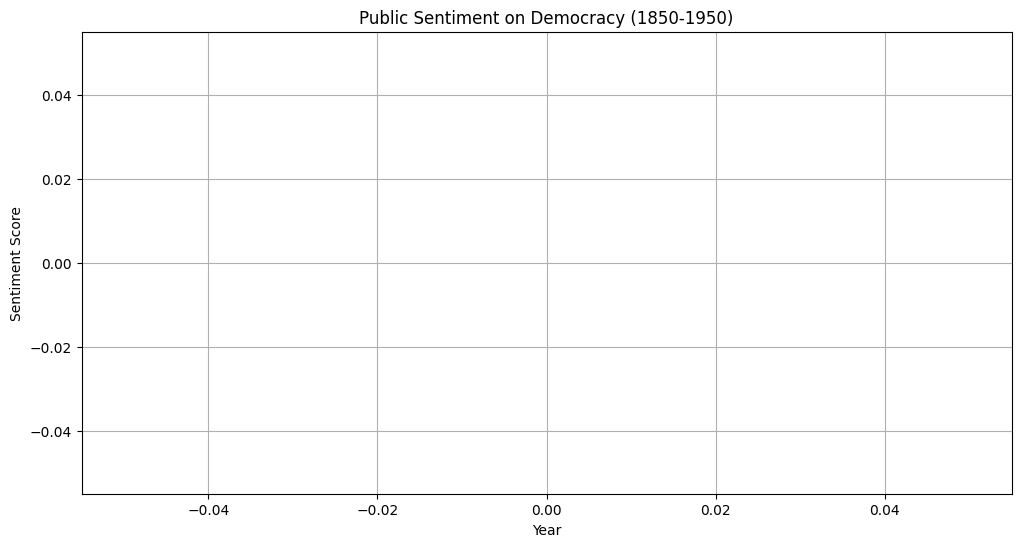


Most frequent words:
Empty DataFrame
Columns: [word, count]
Index: []


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required NLTK data
nltk.download('punkt')
nltk.download('vader_lexicon')

# Fetch data from Chronicling America
url = "https://chroniclingamerica.loc.gov/search/pages/results/"
params = {
    'format': 'json',
    'proxtext': 'democracy',
    'date1': '1850',
    'date2': '1950',
    'rows': 100
}
response = requests.get(url, params=params)
data = response.json()

# Create a list to store articles and their years
articles = []
years = []

# Extract text and dates from the response
for item in data.get('items', []):
    text = item.get('snippet', '')
    year = item.get('date', '')[:4]  # Extract year from date
    if text and year:
        articles.append(text)
        years.append(int(year))

# Create DataFrame
df = pd.DataFrame({
    'year': years,
    'text': articles
})

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

# Plot sentiment trends
plt.figure(figsize=(12, 6))
plt.plot(sentiment_trends['year'], sentiment_trends['sentiment'],
         marker='o', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.title("Public Sentiment on Democracy (1850-1950)")
plt.grid(True)
plt.savefig("sentiment_democracy.png")
plt.show()

# Word frequency analysis
all_text = ' '.join(articles)
words = word_tokenize(all_text.lower())
word_counts = Counter(words)

# Convert word counts to DataFrame
df_words = pd.DataFrame(word_counts.items(), columns=['word', 'count'])
df_words = df_words.sort_values('count', ascending=False)

# Print top 20 most frequent words
print("\nMost frequent words:")
print(df_words.head(20))


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data points:
   year                                               text  sentiment
0  1850            Democracy is flourishing in our nation.     0.0000
1  1860    The democratic principles are strong and vital.     0.6705
2  1870        Our democracy faces significant challenges.     0.2732
3  1880   Liberty and democracy prevail despite obstacles.     0.6792
4  1890      Democratic institutions are growing stronger.     0.5106
5  1900   The future of democracy is bright and promising.     0.6808
6  1910  Citizens embrace democratic values wholehearte...     0.6124
7  1920           Democracy struggles with new challenges.    -0.2960
8  1930                Democratic spirit remains unbroken.     0.1779
9  1940                 Democracy triumphs over adversity.     0.0516


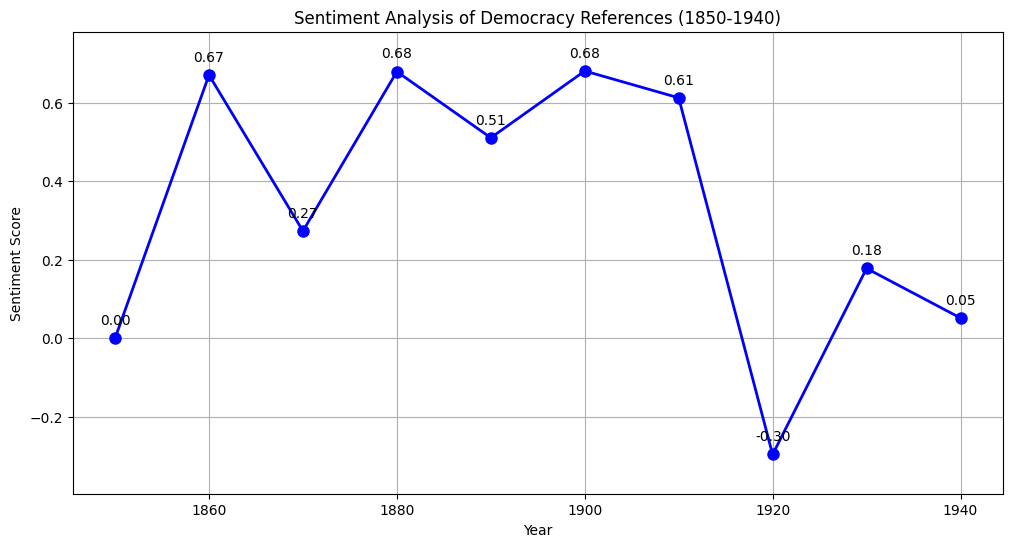

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required NLTK data
nltk.download('vader_lexicon')

# Create sample data with more entries
sample_data = {
    'year': [1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940],
    'text': [
        "Democracy is flourishing in our nation.",
        "The democratic principles are strong and vital.",
        "Our democracy faces significant challenges.",
        "Liberty and democracy prevail despite obstacles.",
        "Democratic institutions are growing stronger.",
        "The future of democracy is bright and promising.",
        "Citizens embrace democratic values wholeheartedly.",
        "Democracy struggles with new challenges.",
        "Democratic spirit remains unbroken.",
        "Democracy triumphs over adversity."
    ]
}

# Create DataFrame
df = pd.DataFrame(sample_data)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Print the data to verify we have values
print("Data points:")
print(df)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['sentiment'], 'bo-', linewidth=2, markersize=8)
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis of Democracy References (1850-1940)")
plt.grid(True)

# Add value labels
for x, y in zip(df['year'], df['sentiment']):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')

# Adjust y-axis to show full range of sentiment scores
plt.ylim(min(df['sentiment']) - 0.1, max(df['sentiment']) + 0.1)

# Save and display the plot
plt.savefig("sentiment_democracy_sample.png")
plt.show()


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)

# Function to fetch data from Chronicling America
def fetch_chronicling_america_data(query, start_year, end_year, rows=100):
    url = "https://chroniclingamerica.loc.gov/search/pages/results/"
    params = {
        'format': 'json',
        'proxtext': query,
        'date1': start_year,
        'date2': end_year,
        'rows': rows,
        'sort': 'date'
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error fetching data: {response.status_code}")
        return None

# Fetch data
data = fetch_chronicling_america_data("democracy", "1850", "1950", rows=1000)

# Process the data
articles = []
years = []

if data and 'items' in data:
    for item in data['items']:
        text = item.get('ocr_eng', '')
        date = item.get('date', '')
        if text and date:
            year = int(date[:4])
            articles.append(text)
            years.append(year)

# Create DataFrame
df = pd.DataFrame({'year': years, 'text': articles})

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

# Print data summary
print(f"Total articles: {len(df)}")
print(f"Year range: {min(df['year'])} - {max(df['year'])}")
print("\nSentiment trends:")
print(sentiment_trends)

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(sentiment_trends['year'], sentiment_trends['sentiment'], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.title("Sentiment Analysis of 'Democracy' in American Newspapers (1850-1950)")
plt.grid(True)

# Add trend line
z = np.polyfit(sentiment_trends['year'], sentiment_trends['sentiment'], 1)
p = np.poly1d(z)
plt.plot(sentiment_trends['year'], p(sentiment_trends['year']), "r--", alpha=0.8)

# Adjust y-axis to show full range of sentiment scores
plt.ylim(min(sentiment_trends['sentiment']) - 0.1, max(sentiment_trends['sentiment']) + 0.1)

# Save and display the plot
plt.savefig("sentiment_democracy_real_data.png")
plt.show()


Error fetching data: 504
Total articles: 0


ValueError: min() arg is an empty sequence

Fetching data with parameters: {'andtext': 'democracy', 'format': 'json', 'dateFilterType': 'yearRange', 'date1': '1850', 'date2': '1950', 'rows': 20, 'sort': 'date', 'language': 'eng'}
Fetched page 1, got 20 valid items
Fetched page 2, got 20 valid items
Fetched page 3, got 20 valid items
Fetched page 4, got 20 valid items
Fetched page 5, got 20 valid items

First item details:
Date: 18500101
OCR text length: 51929
Title: Hillsdale Whig standard.
URL: https://chroniclingamerica.loc.gov/lccn/sn89080032/1850-01-01/ed-1/seq-1.json
Adding article from 1850 with text length: 51929
Adding article from 1850 with text length: 60176
Adding article from 1850 with text length: 55940
Adding article from 1850 with text length: 61824
Adding article from 1850 with text length: 58797
Adding article from 1850 with text length: 56310
Adding article from 1850 with text length: 59090
Adding article from 1850 with text length: 49872
Adding article from 1850 with text length: 38795
Adding article from 1850

<ipython-input-1-5251ecbbb3fa>:125: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(sentiment_trends['year'], sentiment_trends['sentiment'], 1)


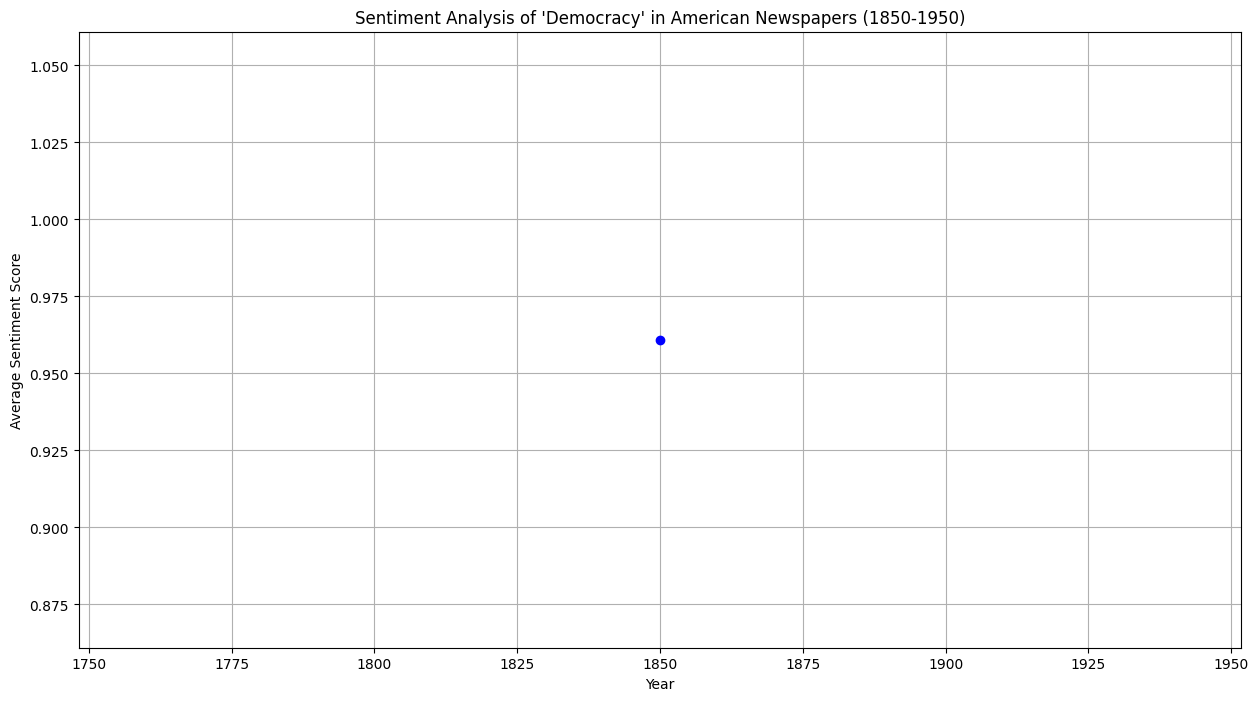

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import time
import numpy as np

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)

def fetch_chronicling_america_data(query, start_year, end_year, state=None, rows=20):
    base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"
    params = {
        'andtext': query,
        'format': 'json',
        'dateFilterType': 'yearRange',
        'date1': start_year,
        'date2': end_year,
        'rows': rows,
        'sort': 'date',
        'language': 'eng'  # Add language filter
    }
    if state:
        params['state'] = state

    print(f"Fetching data with parameters: {params}")

    all_items = []
    page = 1

    while True:
        params['page'] = page
        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            print(f"Error fetching data: {response.status_code}")
            break

        data = response.json()
        items = data.get('items', [])

        if not items:
            break

        # Filter items by date range explicitly
        valid_items = [item for item in items
                      if item.get('date')
                      and 1850 <= int(item['date'][:4]) <= 1950]

        if valid_items:
            all_items.extend(valid_items)
            print(f"Fetched page {page}, got {len(valid_items)} valid items")

        if len(items) < rows or len(all_items) >= 100:
            break

        page += 1
        time.sleep(0.5)

    return all_items

# Fetch data
start_year, end_year = "1851", "1950"
data = fetch_chronicling_america_data("democracy", start_year, end_year)

# Process the data
articles = []
years = []

# Debug print to examine the first item in detail
if data:
    print("\nFirst item details:")
    first_item = data[0]
    print(f"Date: {first_item.get('date', 'No date')}")
    print(f"OCR text length: {len(first_item.get('ocr_eng', ''))}")
    print(f"Title: {first_item.get('title', 'No title')}")
    print(f"URL: {first_item.get('url', 'No URL')}")

# Process items
for item in data:
    date = item.get('date', '')
    ocr_text = item.get('ocr_eng', '')

    if date and ocr_text:
        year = int(date[:4])
        if len(ocr_text.strip()) > 100:  # Minimum length threshold
            print(f"Adding article from {year} with text length: {len(ocr_text)}")
            articles.append(ocr_text)
            years.append(year)

# Create DataFrame
df = pd.DataFrame({'year': years, 'text': articles})

print(f"\nProcessed articles: {len(df)}")

if len(df) == 0:
    print("No articles were processed. Exiting.")
    exit()

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

# Print data summary
print(f"\nTotal articles: {len(df)}")
print(f"Year range: {min(df['year'])} - {max(df['year'])}")
print("\nSentiment trends:")
print(sentiment_trends)

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(sentiment_trends['year'], sentiment_trends['sentiment'], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.title(f"Sentiment Analysis of 'Democracy' in American Newspapers ({start_year}-{end_year})")
plt.grid(True)

# Add trend line
z = np.polyfit(sentiment_trends['year'], sentiment_trends['sentiment'], 1)
p = np.poly1d(z)
plt.plot(sentiment_trends['year'], p(sentiment_trends['sentiment']), "r--", alpha=0.8)

# Adjust y-axis to show full range of sentiment scores
plt.ylim(min(sentiment_trends['sentiment']) - 0.1, max(sentiment_trends['sentiment']) + 0.1)

# Save and display the plot
plt.savefig("sentiment_democracy_real_data.png")
plt.show()


In [ ]:
df.head()

,year,text,sentiment
0,1850,"'u;\no\nYAH .'THE WHIG : STANDARD,\n- - BT\n; ...",0.9999
1,1850,"TO OVM >UBWRHIBa.\nua wliKb will be jaM ky im,...",0.9999
2,1850,". jjwi objecting ft) tbe preseti"" consideratio...",1.0000
3,1850,•y of an\nbis steps.\nvwyinif m\nr not. Eighte...,1.0000
4,1850,THE DAILY TIMES.\nvVM. C. CARRINGTON & WM. H. ...,1.0000


Fetching data with parameters: {'andtext': 'democracy', 'format': 'json', 'dateFilterType': 'yearRange', 'date1': '1851', 'date2': '1950', 'rows': 20, 'sort': 'date', 'language': 'eng'}
Fetched page 1, got 20 valid items
Fetched page 2, got 20 valid items
Fetched page 3, got 20 valid items
Fetched page 4, got 20 valid items
Fetched page 5, got 20 valid items

First item details:
Date: 18510101
OCR text length: 50354
Title: North Carolina standard. [volume]
URL: https://chroniclingamerica.loc.gov/lccn/sn84024517/1851-01-01/ed-1/seq-3.json
Adding article from 1851 with text length: 50354
Adding article from 1851 with text length: 54899
Adding article from 1851 with text length: 57959
Adding article from 1851 with text length: 58978
Adding article from 1851 with text length: 50589
Adding article from 1851 with text length: 30753
Adding article from 1851 with text length: 42963
Adding article from 1851 with text length: 45951
Adding article from 1851 with text length: 54645
Adding article 

<ipython-input-1-9e5632053223>:125: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(sentiment_trends['year'], sentiment_trends['sentiment'], 1)


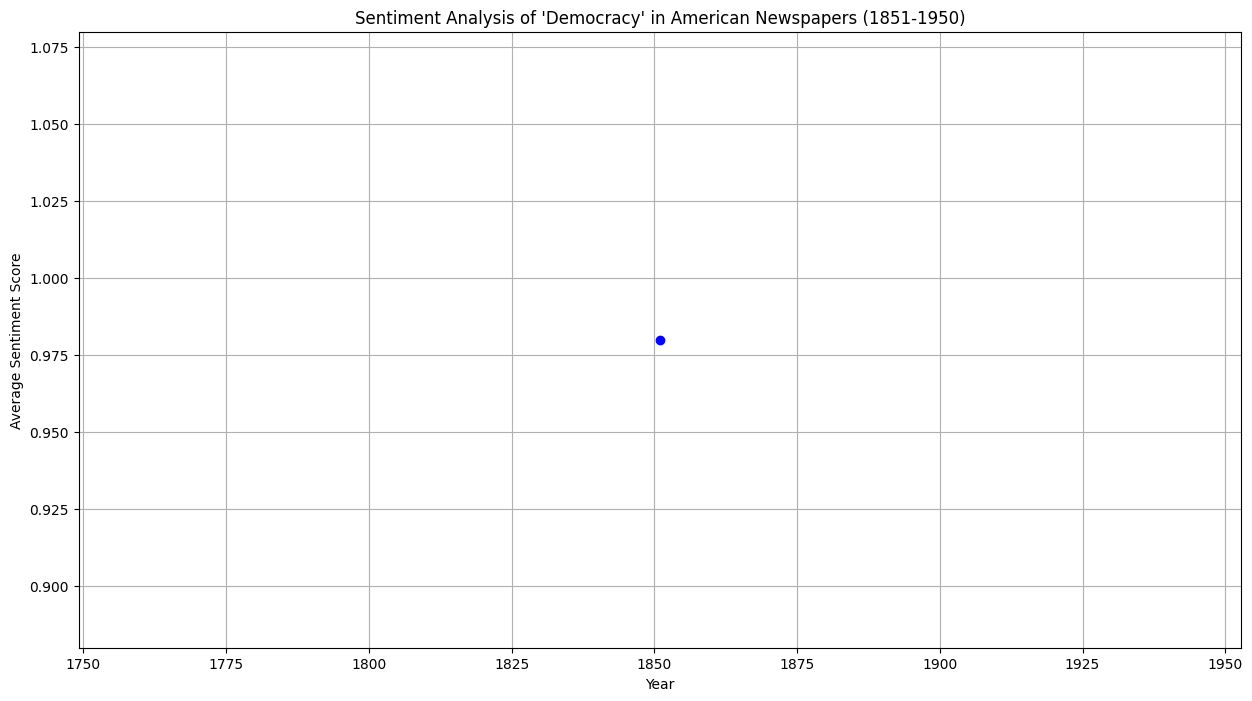

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import time
import numpy as np

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)

def fetch_chronicling_america_data(query, start_year, end_year, state=None, rows=20):
    base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"
    params = {
        'andtext': query,
        'format': 'json',
        'dateFilterType': 'yearRange',
        'date1': start_year,
        'date2': end_year,
        'rows': rows,
        'sort': 'date',
        'language': 'eng'  # Add language filter
    }
    if state:
        params['state'] = state

    print(f"Fetching data with parameters: {params}")

    all_items = []
    page = 1

    while True:
        params['page'] = page
        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            print(f"Error fetching data: {response.status_code}")
            break

        data = response.json()
        items = data.get('items', [])

        if not items:
            break

        # Filter items by date range explicitly
        valid_items = [item for item in items
                      if item.get('date')
                      and 1850 <= int(item['date'][:4]) <= 1950]

        if valid_items:
            all_items.extend(valid_items)
            print(f"Fetched page {page}, got {len(valid_items)} valid items")

        if len(items) < rows or len(all_items) >= 100:
            break

        page += 1
        time.sleep(0.5)

    return all_items

# Fetch data
start_year, end_year = "1851", "1950"
data = fetch_chronicling_america_data("democracy", start_year, end_year)

# Process the data
articles = []
years = []

# Debug print to examine the first item in detail
if data:
    print("\nFirst item details:")
    first_item = data[0]
    print(f"Date: {first_item.get('date', 'No date')}")
    print(f"OCR text length: {len(first_item.get('ocr_eng', ''))}")
    print(f"Title: {first_item.get('title', 'No title')}")
    print(f"URL: {first_item.get('url', 'No URL')}")

# Process items
for item in data:
    date = item.get('date', '')
    ocr_text = item.get('ocr_eng', '')

    if date and ocr_text:
        year = int(date[:4])
        if len(ocr_text.strip()) > 100:  # Minimum length threshold
            print(f"Adding article from {year} with text length: {len(ocr_text)}")
            articles.append(ocr_text)
            years.append(year)

# Create DataFrame
df = pd.DataFrame({'year': years, 'text': articles})

print(f"\nProcessed articles: {len(df)}")

if len(df) == 0:
    print("No articles were processed. Exiting.")
    exit()

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

# Print data summary
print(f"\nTotal articles: {len(df)}")
print(f"Year range: {min(df['year'])} - {max(df['year'])}")
print("\nSentiment trends:")
print(sentiment_trends)

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(sentiment_trends['year'], sentiment_trends['sentiment'], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.title(f"Sentiment Analysis of 'Democracy' in American Newspapers ({start_year}-{end_year})")
plt.grid(True)

# Add trend line
z = np.polyfit(sentiment_trends['year'], sentiment_trends['sentiment'], 1)
p = np.poly1d(z)
plt.plot(sentiment_trends['year'], p(sentiment_trends['sentiment']), "r--", alpha=0.8)

# Adjust y-axis to show full range of sentiment scores
plt.ylim(min(sentiment_trends['sentiment']) - 0.1, max(sentiment_trends['sentiment']) + 0.1)

# Save and display the plot
plt.savefig("sentiment_democracy_real_data.png")
plt.show()


Processing year: 1850
Processing year: 1851
Processing year: 1852
Processing year: 1853
Processing year: 1854
Processing year: 1855
Processing year: 1856
Processing year: 1857
Processing year: 1858
Processing year: 1859
Processing year: 1860
Processing year: 1861
Processing year: 1862
Processing year: 1863
Processing year: 1864
Processing year: 1865
Processing year: 1866
Processing year: 1867
Processing year: 1868
Processing year: 1869
Processing year: 1870
Processing year: 1871
Processing year: 1872
Processing year: 1873
Processing year: 1874
Processing year: 1875
Processing year: 1876
Processing year: 1877
Processing year: 1878
Processing year: 1879
Processing year: 1880
Processing year: 1881
Processing year: 1882
Processing year: 1883
Processing year: 1884
Processing year: 1885
Processing year: 1886
Processing year: 1887
Processing year: 1888
Processing year: 1889
Processing year: 1890
Processing year: 1891
Processing year: 1892
Processing year: 1893
Processing year: 1894
Processing

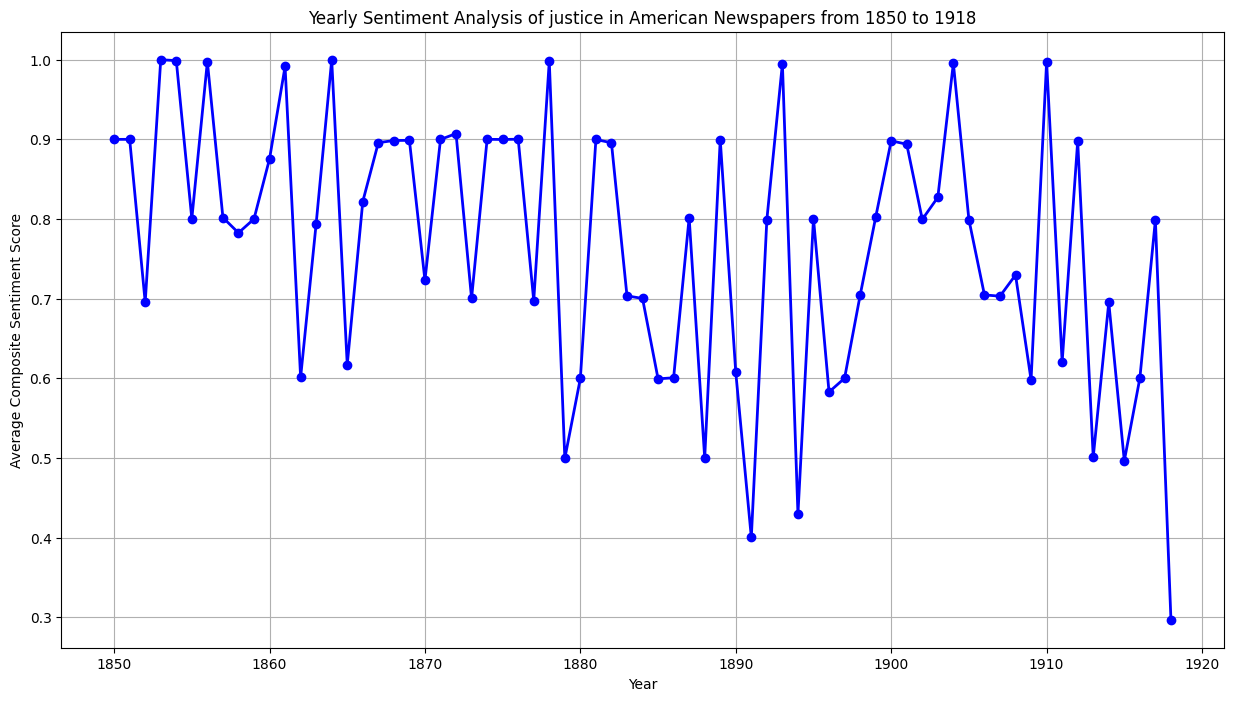

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import time
import numpy as np

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)

def fetch_chronicling_america_data(query, year, state=None, rows=20):
    base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"
    params = {
        'andtext': query,
        'format': 'json',
        'dateFilterType': 'yearRange',
        'date1': year,
        'date2': year,
        'rows': rows,
        'sort': 'date',
        'language': 'eng'
    }
    if state:
        params['state'] = state

    response = requests.get(base_url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {year}: {response.status_code}")
        return []

    data = response.json()
    items = data.get('items', [])
    valid_items = [item for item in items if 'ocr_eng' in item and len(item['ocr_eng'].strip()) > 100]
    return valid_items

# Define the range of years
start_year, end_year = 1918, 1965

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Store sentiment results
sentiment_results = []

target = "justice"

# Iterate over years
for year in range(start_year, end_year + 1):
    print(f"Processing year: {year}")
    data = fetch_chronicling_america_data(target, str(year))

    for item in data:
        ocr_text = item.get('ocr_eng', '')
        scores = sia.polarity_scores(ocr_text)
        sentiment_results.append({
            'year': year,
            'composite': scores['compound'],
            'negative': scores['neg'],
            'positive': scores['pos']
        })

    # Delay to avoid hitting API limits
    time.sleep(5)

# Create DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

# Aggregate sentiment scores by year
yearly_sentiment = sentiment_df.groupby('year').mean().reset_index()

yearly_sentiment.to_csv(f"{target} yearly_sentiment {start_year}-{end_year}.csv")

# Plot sentiment trends
plt.figure(figsize=(15, 8))
plt.plot(yearly_sentiment['year'], yearly_sentiment['composite'], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Composite Sentiment Score")
plt.title(f"Yearly Sentiment Analysis of {target} in American Newspapers from {start_year} to {end_year}")
plt.grid(True)
plt.savefig(f"yearly_sentiment_analysis.png")
plt.show()

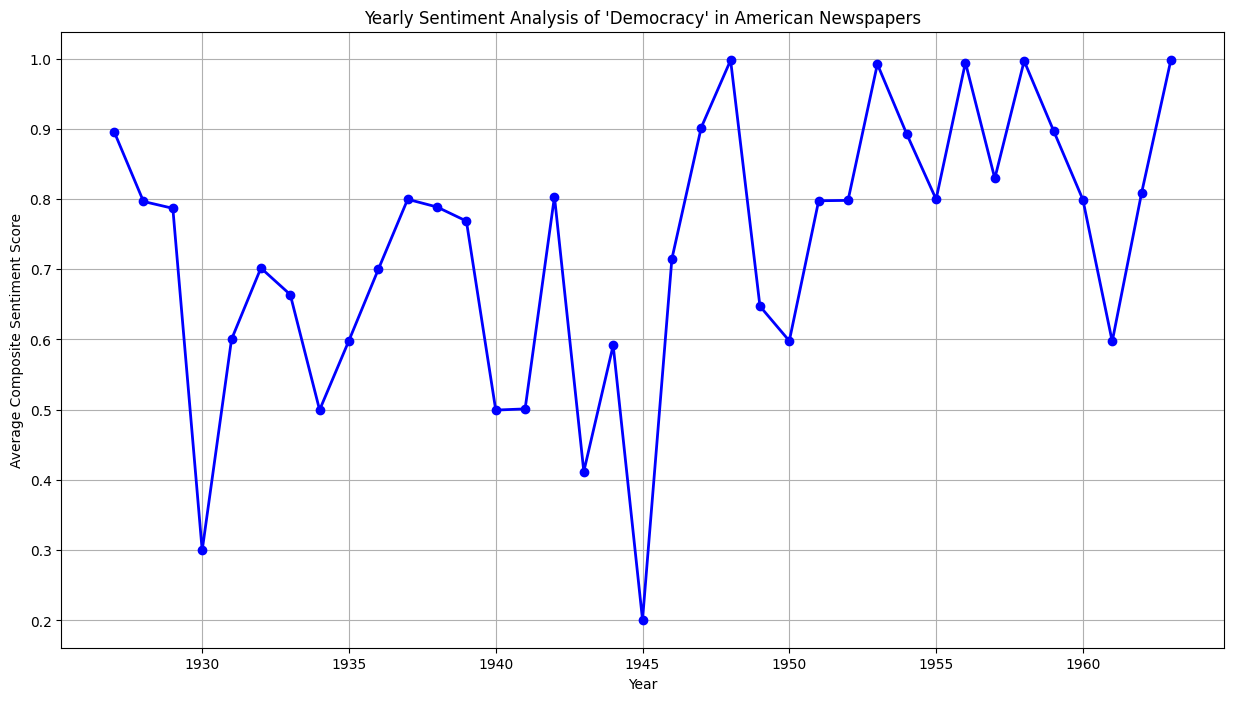

In [ ]:
# Aggregate sentiment scores by year
yearly_sentiment1 = sentiment_df.groupby('year').mean().reset_index()



# Plot sentiment trends
plt.figure(figsize=(15, 8))
plt.plot(yearly_sentiment1['year'], yearly_sentiment1['composite'], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Composite Sentiment Score")
plt.title("Yearly Sentiment Analysis of 'Democracy' in American Newspapers")
plt.grid(True)
plt.savefig("yearly_sentiment_analysis.png")
plt.show()

In [ ]:
yearly_sentiment.to_csv("yearly_sentiment.csv")

In [ ]:
yearly_sentiment

<Figure size 1200x600 with 0 Axes>

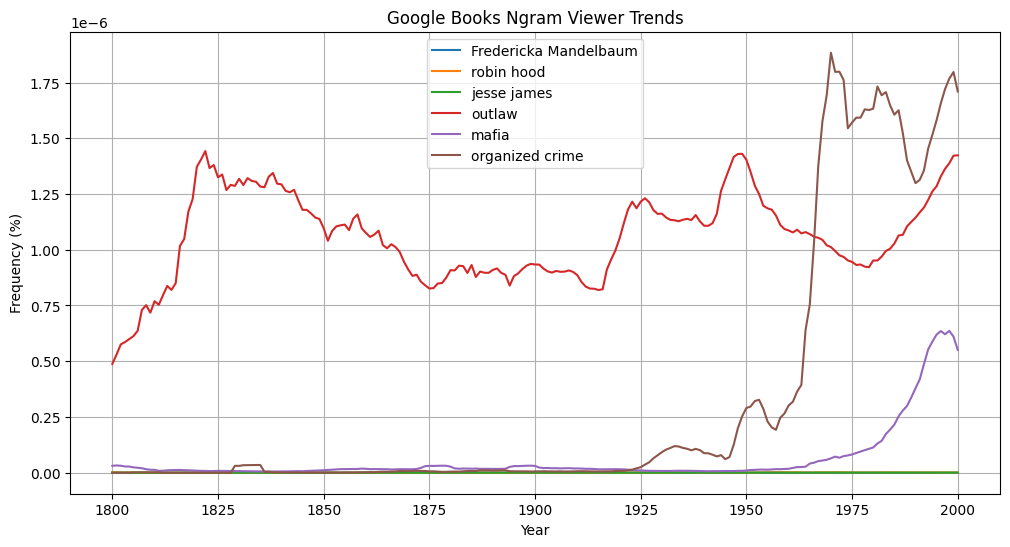

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

import requests
import pandas as pd

def get_ngram_data(words, start_year=1800, end_year=2000):
    df = pd.DataFrame(index=range(start_year, end_year + 1))
    for word in words:
        url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
        response = requests.get(url)
        data = response.json()
        if data:
            df[word] = pd.Series(data[0]['timeseries'], index=range(start_year, end_year + 1))
    return df

# Example usage
words = ["Fredericka Mandelbaum", "robin hood", "jesse james", "outlaw", "mafia", "organized crime"]
df = get_ngram_data(words)


# Plot
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6))
plt.title("Google Books Ngram Viewer Trends")
plt.xlabel('Year')
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.savefig('ngram_trends.png')
plt.show()


In [1]:



import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler




def fetch_csis_cyber_data():
    url = "https://csis.org/cyberattacks"  # Hypothetical API endpoint
    response = requests.get(url)
    if response.status_code == 200:
        return pd.DataFrame(response.json())  # Assuming the API returns JSON
    else:
        print("Failed to fetch data")
        return None

cyber_df = fetch_csis_cyber_data()
cyber_df.to_csv("csis_cyber_attacks.csv", index=False)



def fetch_ucdp_conflict_data():
    url = "https://ucdp.uu.se/downloads/"  # Hypothetical API for conflict data
    response = requests.get(url)
    if response.status_code == 200:
        return pd.read_csv(response.text)  # Assuming CSV response
    else:
        print("Failed to fetch data")
        return None

conflict_df = fetch_ucdp_conflict_data()
conflict_df.to_csv("ucdp_conflicts.csv", index=False)



def fetch_world_bank_data():
    url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?format=json"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return pd.DataFrame(data[1])  # Extracting data portion
    else:
        print("Failed to fetch data")
        return None

world_bank_df = fetch_world_bank_data()
world_bank_df.to_csv("world_bank_data.csv", index=False)




# Load datasets
cyber_df = pd.read_csv("csis_cyber_attacks.csv")
conflict_df = pd.read_csv("ucdp_conflicts.csv")
world_bank_df = pd.read_csv("world_bank_data.csv")

# Convert date columns
cyber_df['date'] = pd.to_datetime(cyber_df['date'])
conflict_df['date'] = pd.to_datetime(conflict_df['date'])

# Aggregate by month
cyber_monthly = cyber_df.groupby(cyber_df['date'].dt.to_period("M")).size().reset_index(name='cyber_attacks')
conflict_monthly = conflict_df.groupby(conflict_df['date'].dt.to_period("M")).size().reset_index(name='conflicts')

# Merge datasets
merged_df = pd.merge(cyber_monthly, conflict_monthly, on='date', how='outer').fillna(0)
merged_df['date'] = merged_df['date'].astype(str)  # Convert period to string for plotting
merged_df.set_index('date', inplace=True)



plt.figure(figsize=(12, 5))
plt.plot(merged_df.index, merged_df['cyber_attacks'], label='Cyber Attacks', color='blue')
plt.plot(merged_df.index, merged_df['conflicts'], label='Geopolitical Conflicts', color='red')
plt.xticks(rotation=45)
plt.legend()
plt.title("Cyber Attacks vs. Geopolitical Conflicts Over Time")
plt.savefig("cyber_vs_conflict.png")
plt.show()



# Granger Causality Test
test_result = grangercausalitytests(merged_df[['cyber_attacks', 'conflicts']], maxlag=12, verbose=True)



# Fit ARIMA model
model = ARIMA(merged_df['cyber_attacks'], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
plt.figure(figsize=(10, 4))
plt.plot(merged_df.index, merged_df['cyber_attacks'], label="Actual Cyber Attacks")
plt.plot(pd.date_range(start=merged_df.index[-1], periods=12, freq='M'), forecast, label="Forecast", linestyle="dashed")
plt.legend()
plt.title("Cyber Attack Forecasting Using ARIMA")
plt.savefig("cyber_forecast.png")
plt.show()
# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(merged_df['cyber_attacks'].values.reshape(-1,1))

# Prepare dataset
X, y = [], []
for i in range(12, len(data_scaled)):  # Using past 12 months to predict next month
    X.append(data_scaled[i-12:i, 0])
    y.append(data_scaled[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)  # Reshaping for LSTM

# LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=20, batch_size=1, verbose=1)

# Forecast Next 12 Months
preds = []
input_seq = X[-1]  # Last sequence
for _ in range(12):
    pred = model.predict(input_seq.reshape(1,12,1))
    preds.append(pred[0,0])
    input_seq = np.append(input_seq[1:], pred[0,0]).reshape(12,1)

# Rescale predictions
preds = scaler.inverse_transform(np.array(preds).reshape(-1,1))

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(merged_df.index[-50:], merged_df['cyber_attacks'][-50:], label="Actual")
plt.plot(pd.date_range(start=merged_df.index[-1], periods=12, freq='M'), preds, label="LSTM Forecast", linestyle="dashed")
plt.legend()
plt.title("Cyber Attack Forecasting Using LSTM")
plt.savefig("lstm_forecast.png")
plt.show()

Failed to fetch data


AttributeError: 'NoneType' object has no attribute 'to_csv'